# LOB Similarity Analysis

## Dependencies installation

In [ ]:
!conda install -y -c rapidsai -c conda-forge -c nvidia \
    cudf=26.04 cupy pandas matplotlib seaborn tqdm jinja2 ipython \
    python=3.11 cuda-version=12

## Multi-Lag Dependency Study

### Objective

The goal of this analysis is to investigate the dependency structure of the Limit Order Book (LOB) by constructing similarity matrices across different temporal lags. This serves as a preliminary step before building graph-based representations (e.g., Glasso or MFCF) for downstream modeling.

---

### Data Representation

We start from raw LOB data and extract only **volume (size) information**:

- Ask size at each level
- Bid size at each level

For each time step, the feature vector is:

ask_0, bid_0, ask_1, bid_1, ..., ask_9, bid_9

where:
- `ask_i` = volume at ask level i
- `bid_i` = volume at bid level i

---

### Temporal Feature Construction

To capture temporal dependencies, we construct lagged features up to a maximum lag `L`:

For each base feature (e.g., `ask_0`), we generate:

ask_0_lag_0, ask_0_lag_1, ..., ask_0_lag_L

The final feature ordering is structured as:

- All lags for `ask_0`
- All lags for `bid_0`
- All lags for `ask_1`
- All lags for `bid_1`
- ...

This ensures that temporal evolution of each variable is grouped together.

---

### Multi-Lag Experiment

We evaluate three different temporal configurations:

- `MAX_LAG = 2`
- `MAX_LAG = 5`
- `MAX_LAG = 10`

This allows us to assess how much additional temporal memory contributes to the dependency structure.

---

### Similarity Measures

For each lag configuration, we compute three types of dependency matrices:

#### 1. Pearson Correlation
- Measures linear relationships
- Sensitive to scale and outliers
- Serves as a baseline

#### 2. Spearman Correlation
- Based on rank transformation
- Captures monotonic relationships
- More robust to non-linearities

#### 3. Normalized Mutual Information (NMI)
- Captures general (non-linear) dependencies
- Computed after quantile-based discretization
- Values in [0, 1]

---

### GPU Acceleration

All computations are performed on GPU using:

- **cuDF** for data handling
- **CuPy** for numerical computation

This allows efficient handling of large matrices and pairwise computations.

---

### Output

For each lag configuration and similarity metric, we produce:

- Full similarity matrix (CSV)
- Heatmap visualization
- Summary statistics (mean off-diagonal similarity)

These outputs are used to compare the structural properties of the LOB under different temporal assumptions.

In [1]:
# ============================================================
# LOB Similarity Matrices - Pearson / Spearman / NMI
# Multi-Lag + Multi-Bin Experiment
# NMI optimized with relative-lag approximation
# ============================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import cudf
import cupy as cp
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"

NUM_LEVELS = 10
LAG_LIST = [150]
N_BINS_LIST = [250, 500]

USE_FLOAT32 = True
NROWS = None

SAVE_CSV = True
PLOT_HEATMAPS = True

MAX_FEATURES_FOR_NMI = np.inf
MAX_FEATURES_FOR_PLOT = np.inf
MAX_FEATURES_HARD_LIMIT = np.inf

# use lag-relative approximation for NMI
USE_RELATIVE_LAG_NMI = True

RANDOM_SEED = 42

Loading CSV on GPU with cuDF...
Loaded shape: (400391, 40)
Extracting size columns...
df_sizes shape: (400391, 20)
Base feature order:
['ask_0', 'bid_0', 'ask_1', 'bid_1', 'ask_2', 'bid_2', 'ask_3', 'bid_3', 'ask_4', 'bid_4', 'ask_5', 'bid_5', 'ask_6', 'bid_6', 'ask_7', 'bid_7', 'ask_8', 'bid_8', 'ask_9', 'bid_9']

RUNNING ANALYSIS FOR MAX_LAG = 150
Building lagged dataframe (memory-efficient)...
df_lagged shape: (400241, 3020)
Number of features: 3020
First 12 feature names:
['ask_0_lag_0', 'ask_0_lag_1', 'ask_0_lag_2', 'ask_0_lag_3', 'ask_0_lag_4', 'ask_0_lag_5', 'ask_0_lag_6', 'ask_0_lag_7', 'ask_0_lag_8', 'ask_0_lag_9', 'ask_0_lag_10', 'ask_0_lag_11']
Expected number of features: 3020
Converting lagged matrix to CuPy array...
X shape: (400241, 3020)
Computing Pearson correlation matrix on GPU...
Pearson done.
Pearson diagonal mean      : 1.000000
Pearson max symmetry error: 2.220446e-16
Computing Spearman correlation matrix on GPU...


Ranking columns for Spearman: 100%|██████████| 3020/3020 [00:02<00:00, 1215.90it/s]


Spearman done.
Spearman diagonal mean      : 1.000000
Spearman max symmetry error: 0.000000e+00

------------------------------------------------------------
Running NMI with n_bins = 250
------------------------------------------------------------
Discretizing for NMI on GPU...


Quantile discretization (bins=250): 100%|██████████| 3020/3020 [00:06<00:00, 457.18it/s]


Computing NMI similarity matrix on GPU (relative-lag approximation)...


Reconstructing full NMI matrix (bins=250): 100%|██████████| 4561710/4561710 [01:53<00:00, 40223.90it/s]


NMI done for bins=250.
NMI (bins=250) diagonal mean      : 1.000000
NMI (bins=250) max symmetry error: 0.000000e+00
NMI mean (off-diagonal): 0.0563
Saved NMI -> /teamspace/studios/this_studio/lob_similarity_nmi_rellag_lag150_bins250.csv
Plotting NMI heatmap for bins=250...


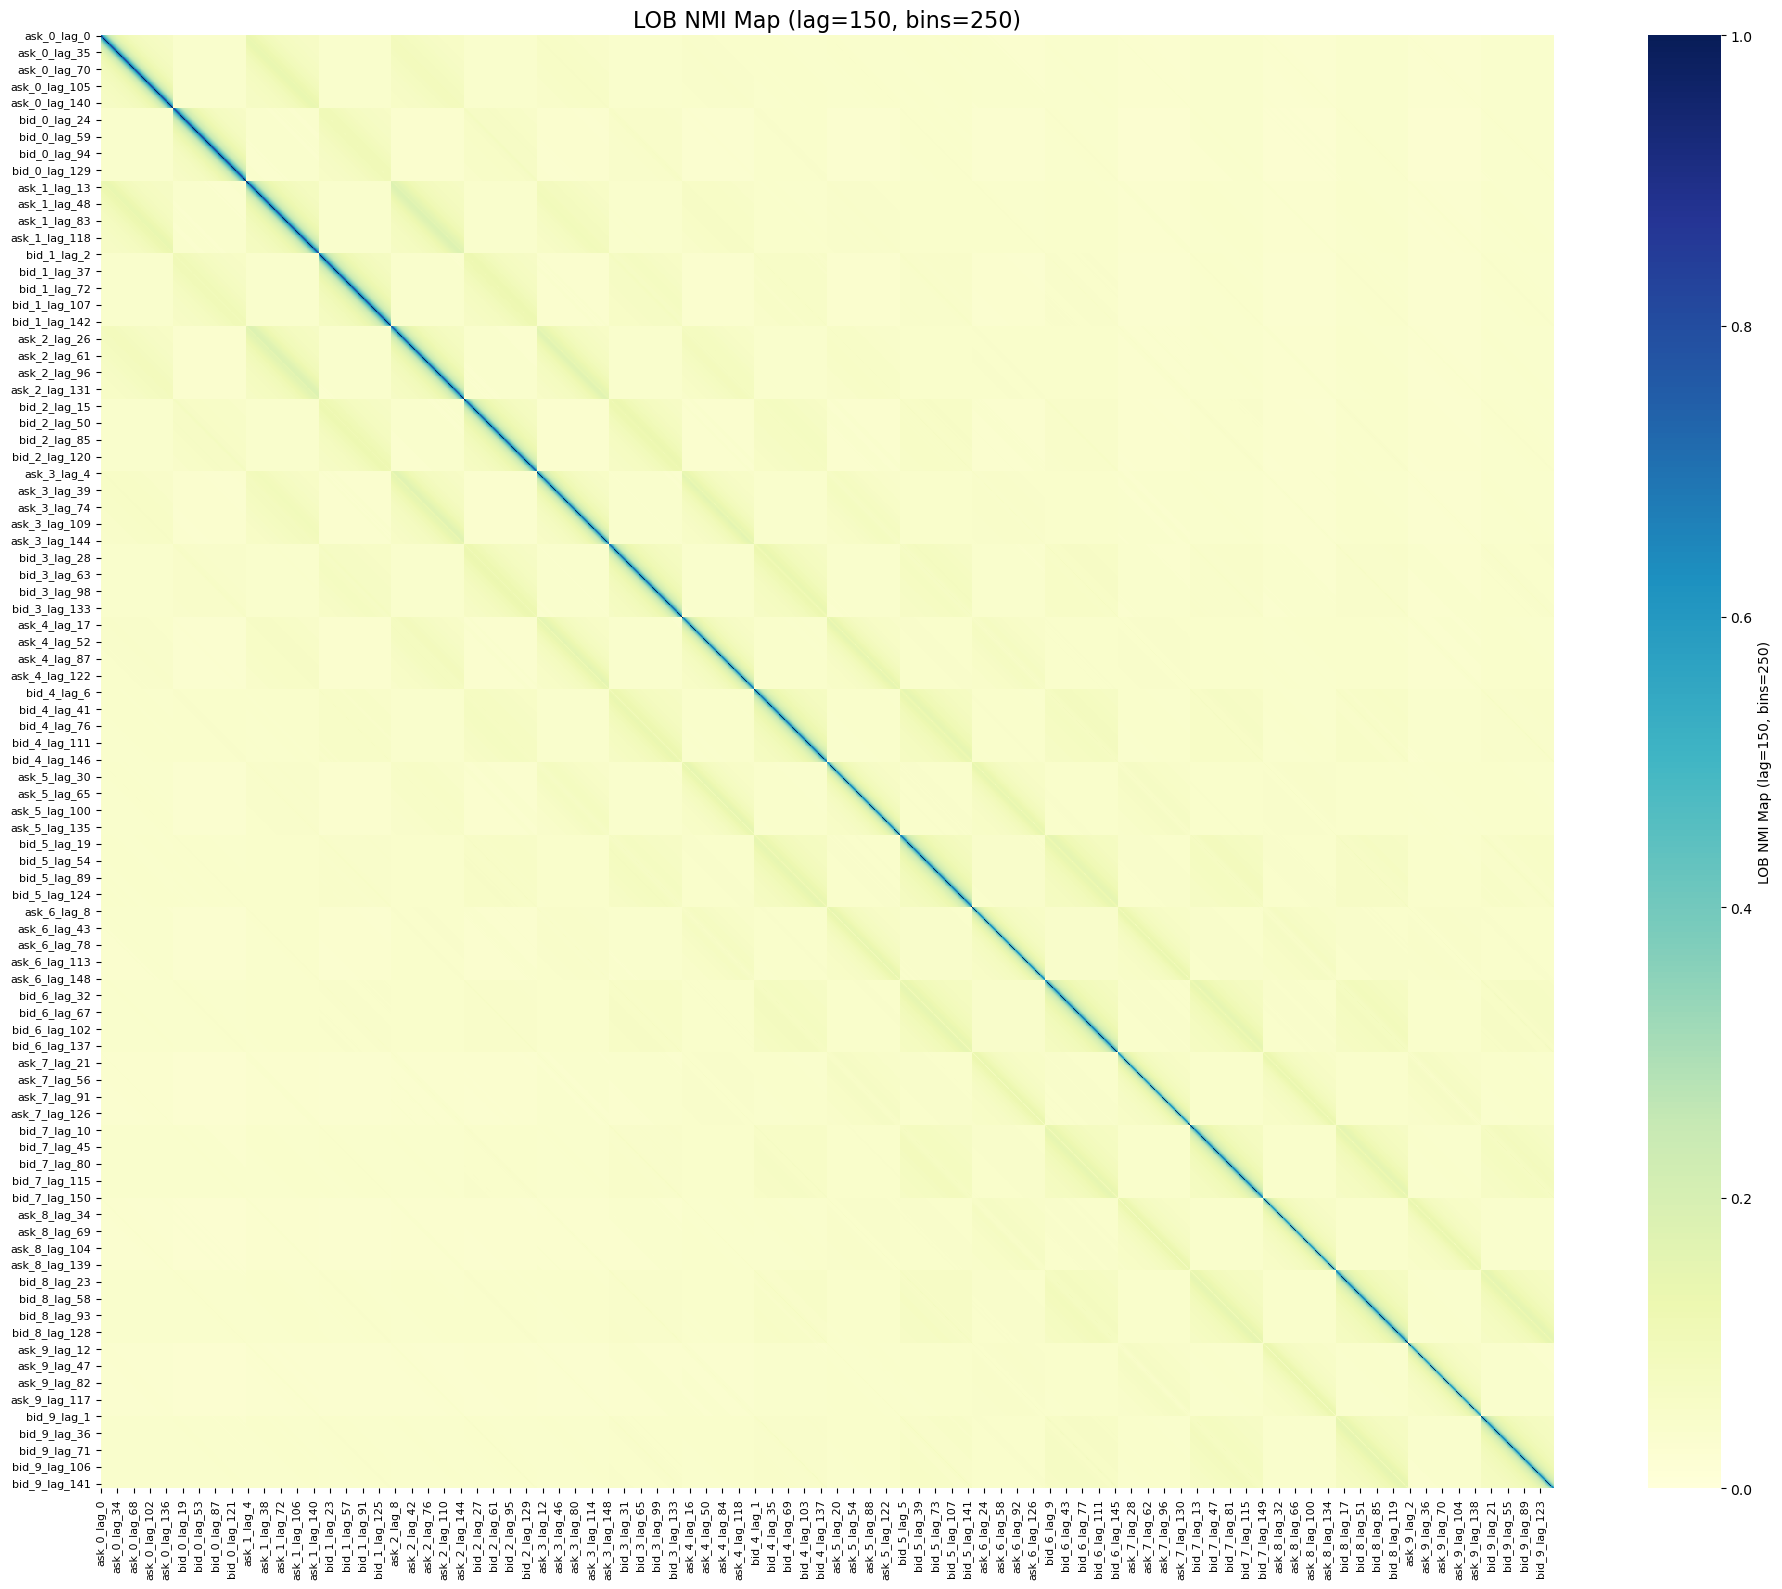


------------------------------------------------------------
Running NMI with n_bins = 500
------------------------------------------------------------
Discretizing for NMI on GPU...


Quantile discretization (bins=500): 100%|██████████| 3020/3020 [00:06<00:00, 454.59it/s]


Computing NMI similarity matrix on GPU (relative-lag approximation)...


Reconstructing full NMI matrix (bins=500): 100%|██████████| 4561710/4561710 [01:53<00:00, 40322.33it/s]


NMI done for bins=500.
NMI (bins=500) diagonal mean      : 1.000000
NMI (bins=500) max symmetry error: 0.000000e+00
NMI mean (off-diagonal): 0.0770
Saved NMI -> /teamspace/studios/this_studio/lob_similarity_nmi_rellag_lag150_bins500.csv
Plotting NMI heatmap for bins=500...


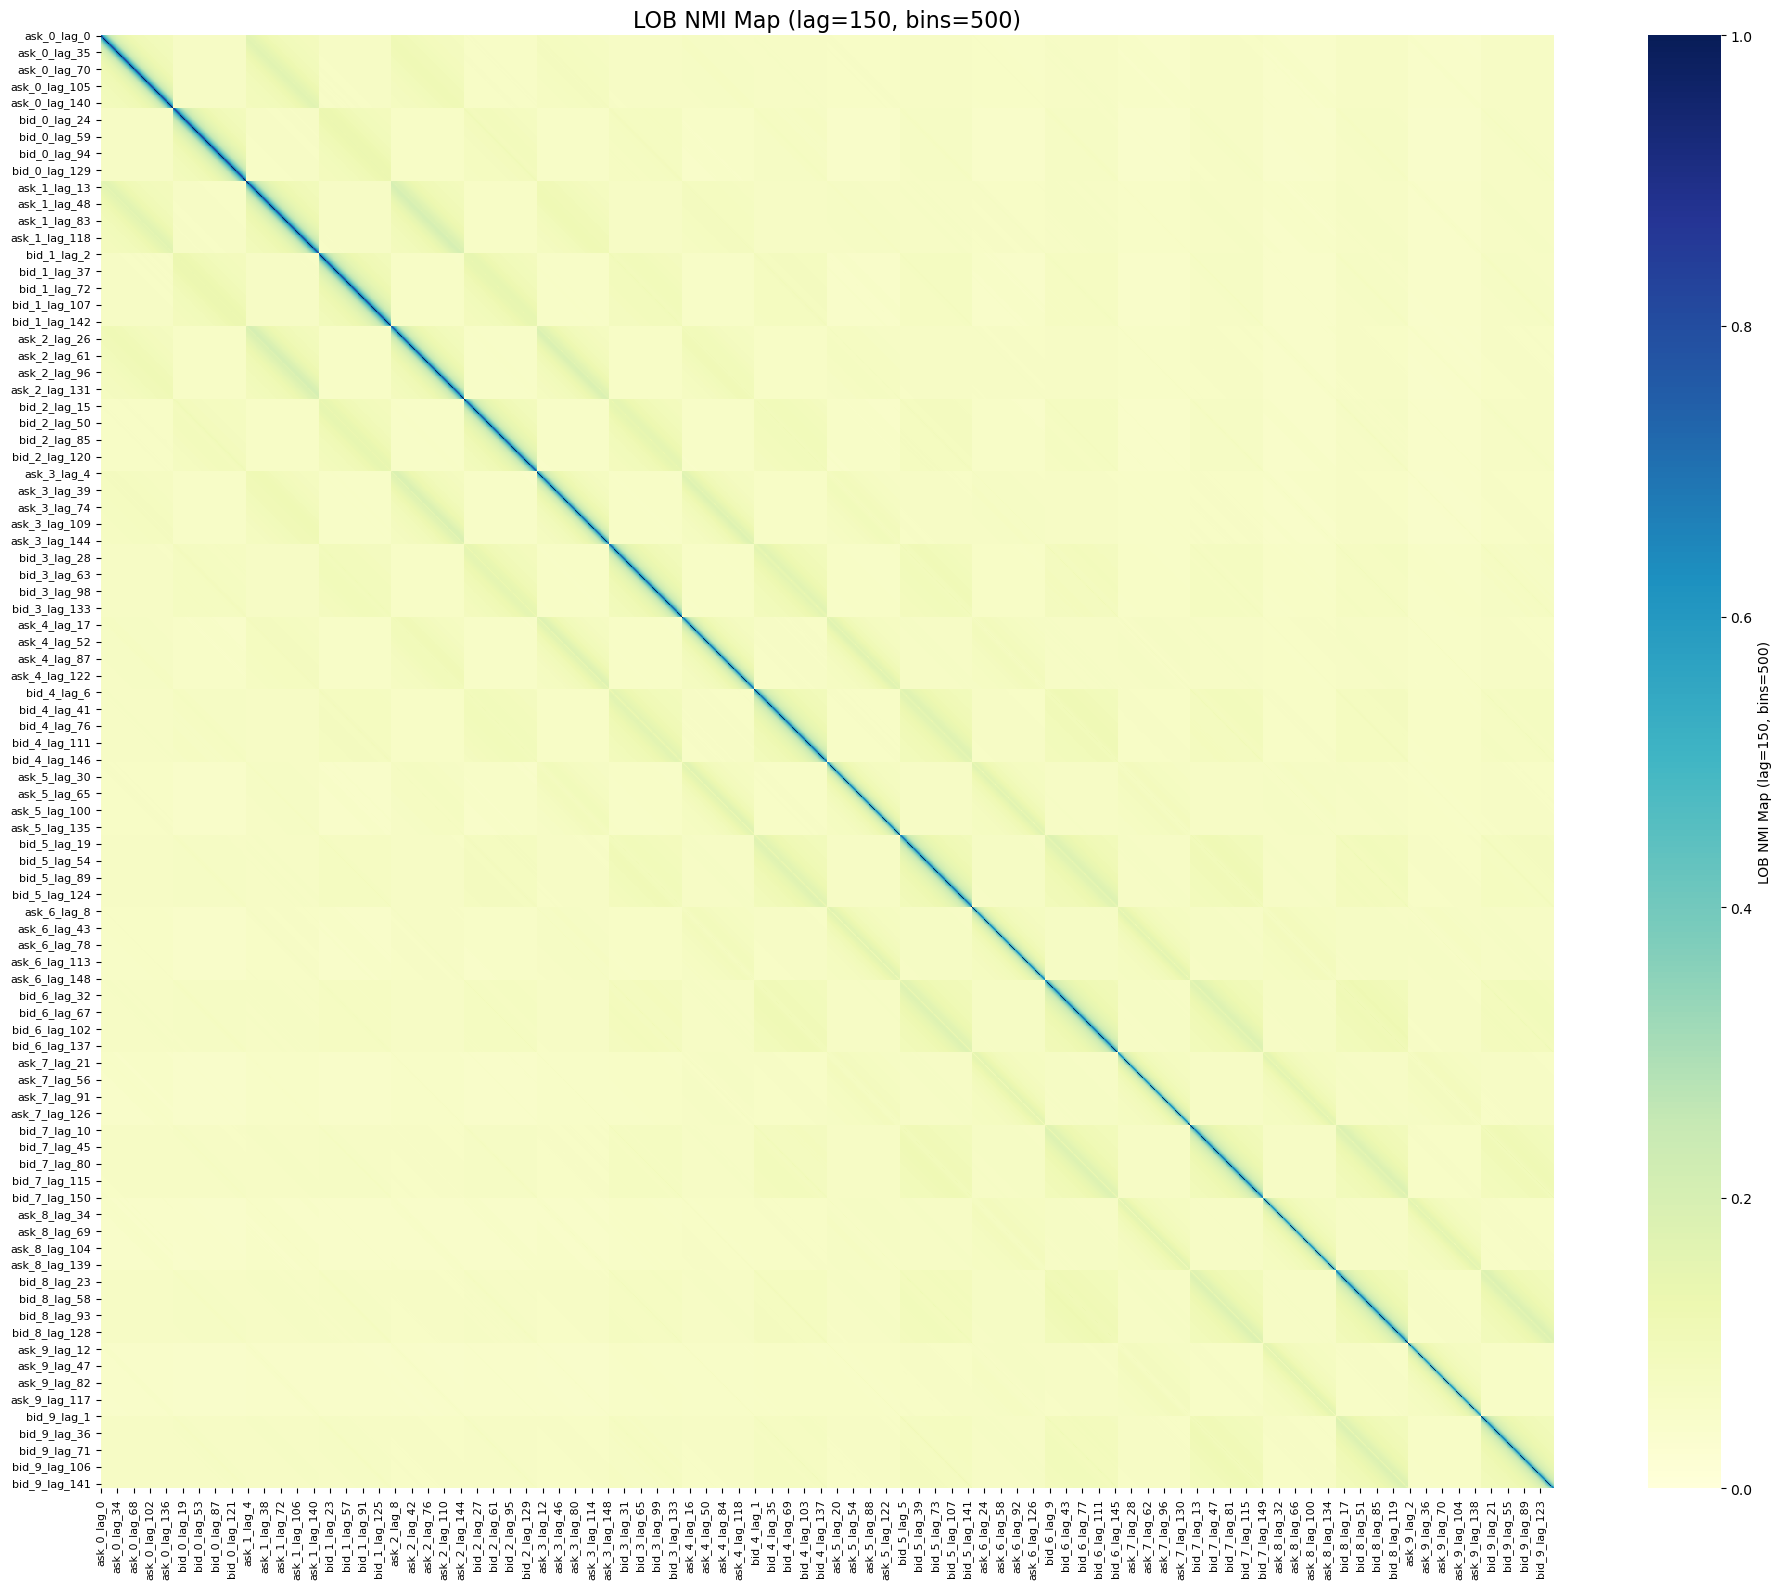


Saved files:
Pearson  -> /teamspace/studios/this_studio/lob_similarity_pearson_lag150.csv
Spearman -> /teamspace/studios/this_studio/lob_similarity_spearman_lag150.csv

Plotting Pearson...


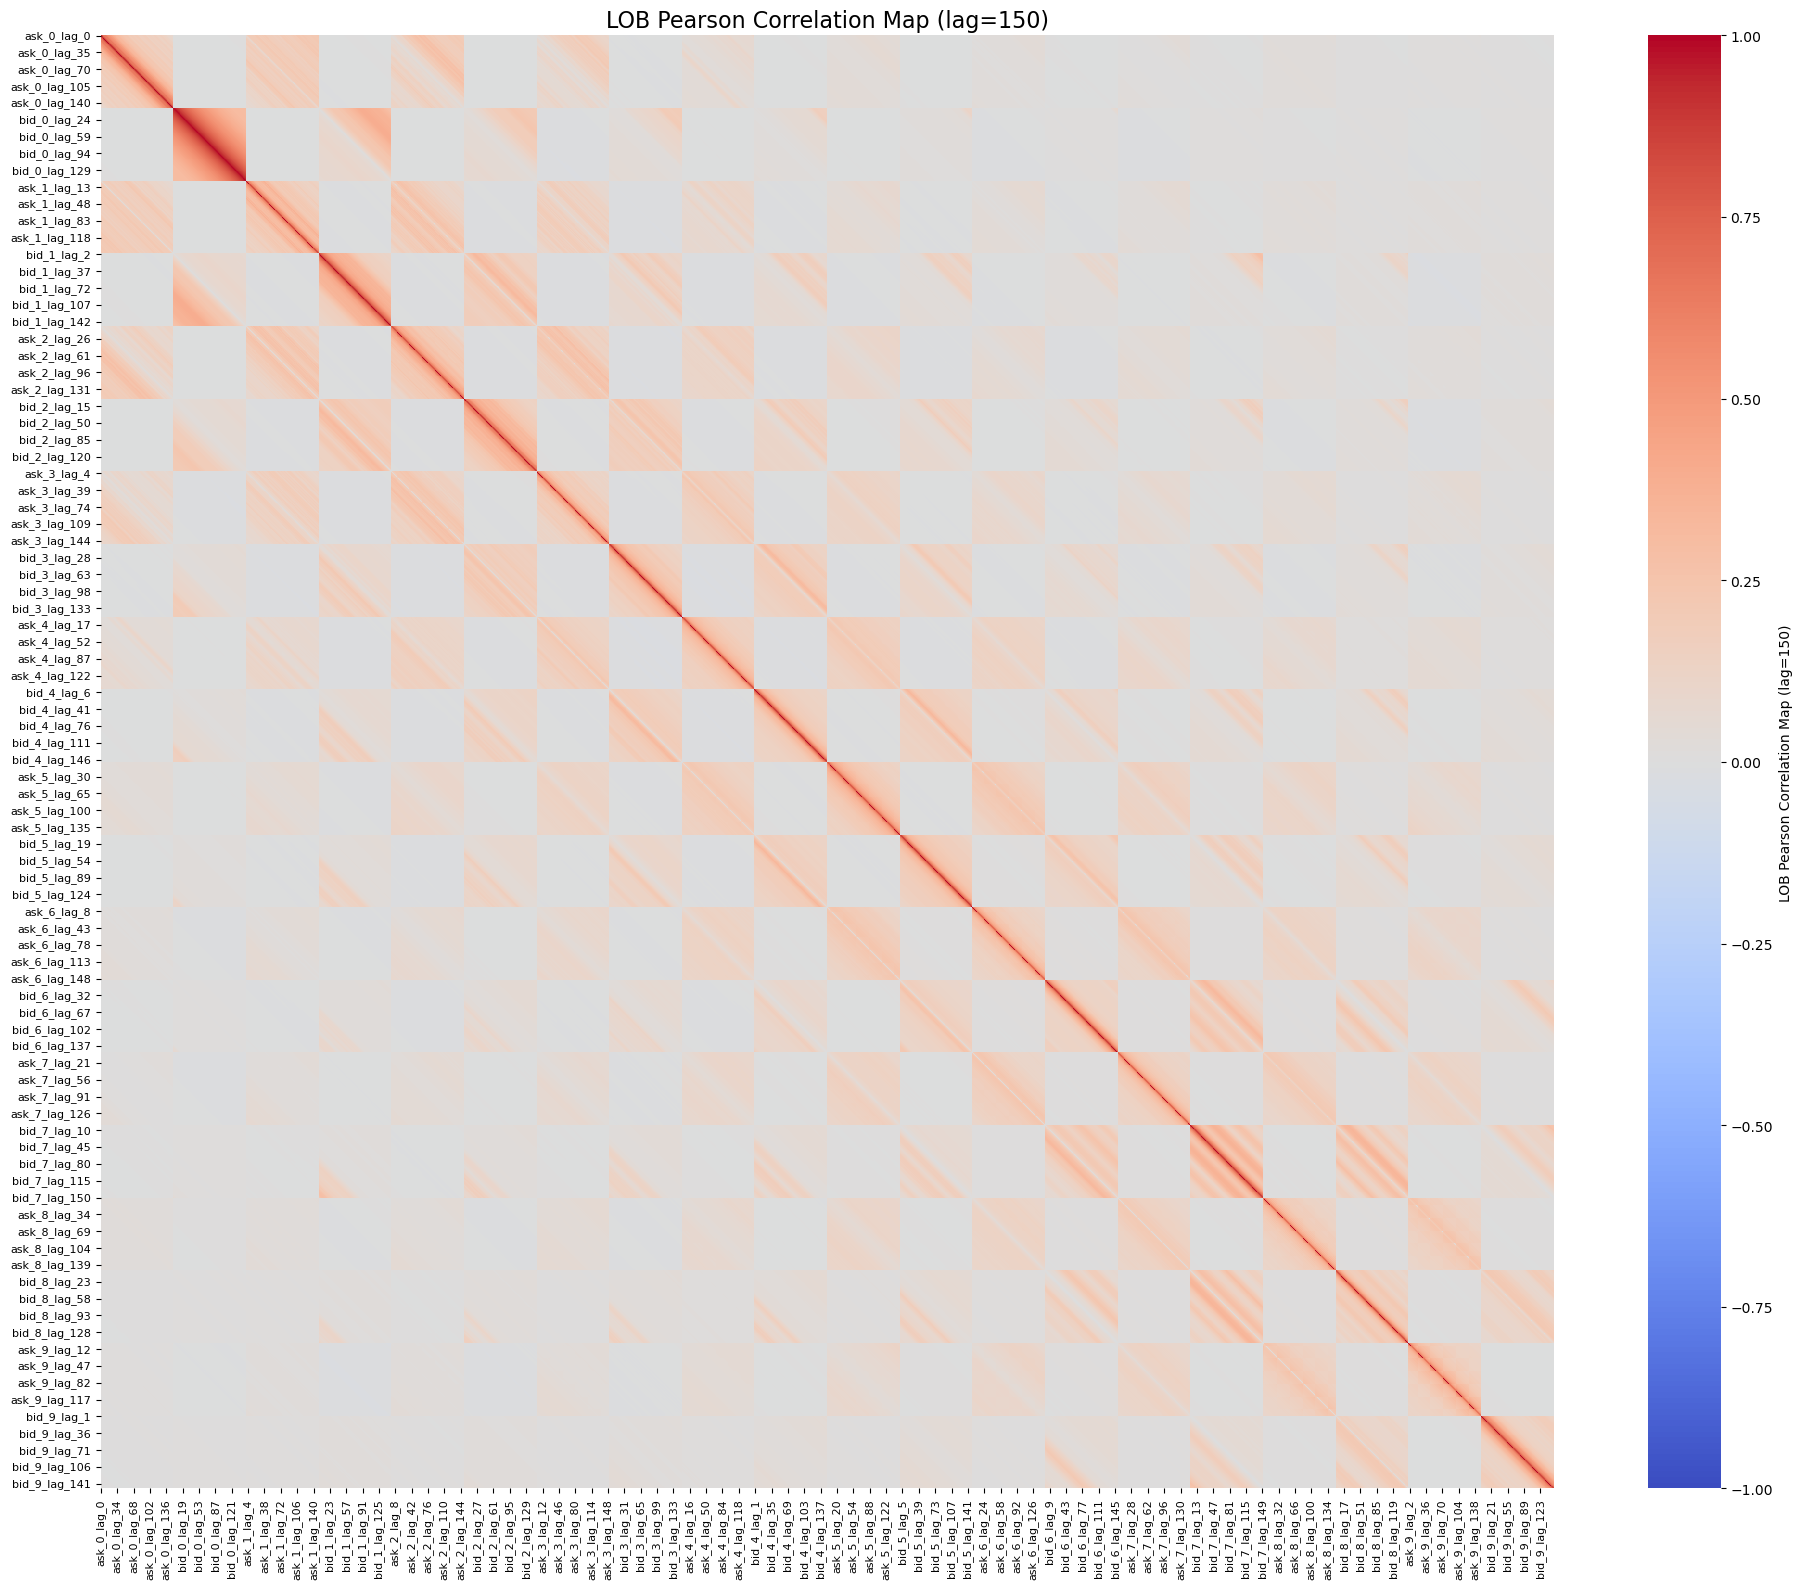

Plotting Spearman...


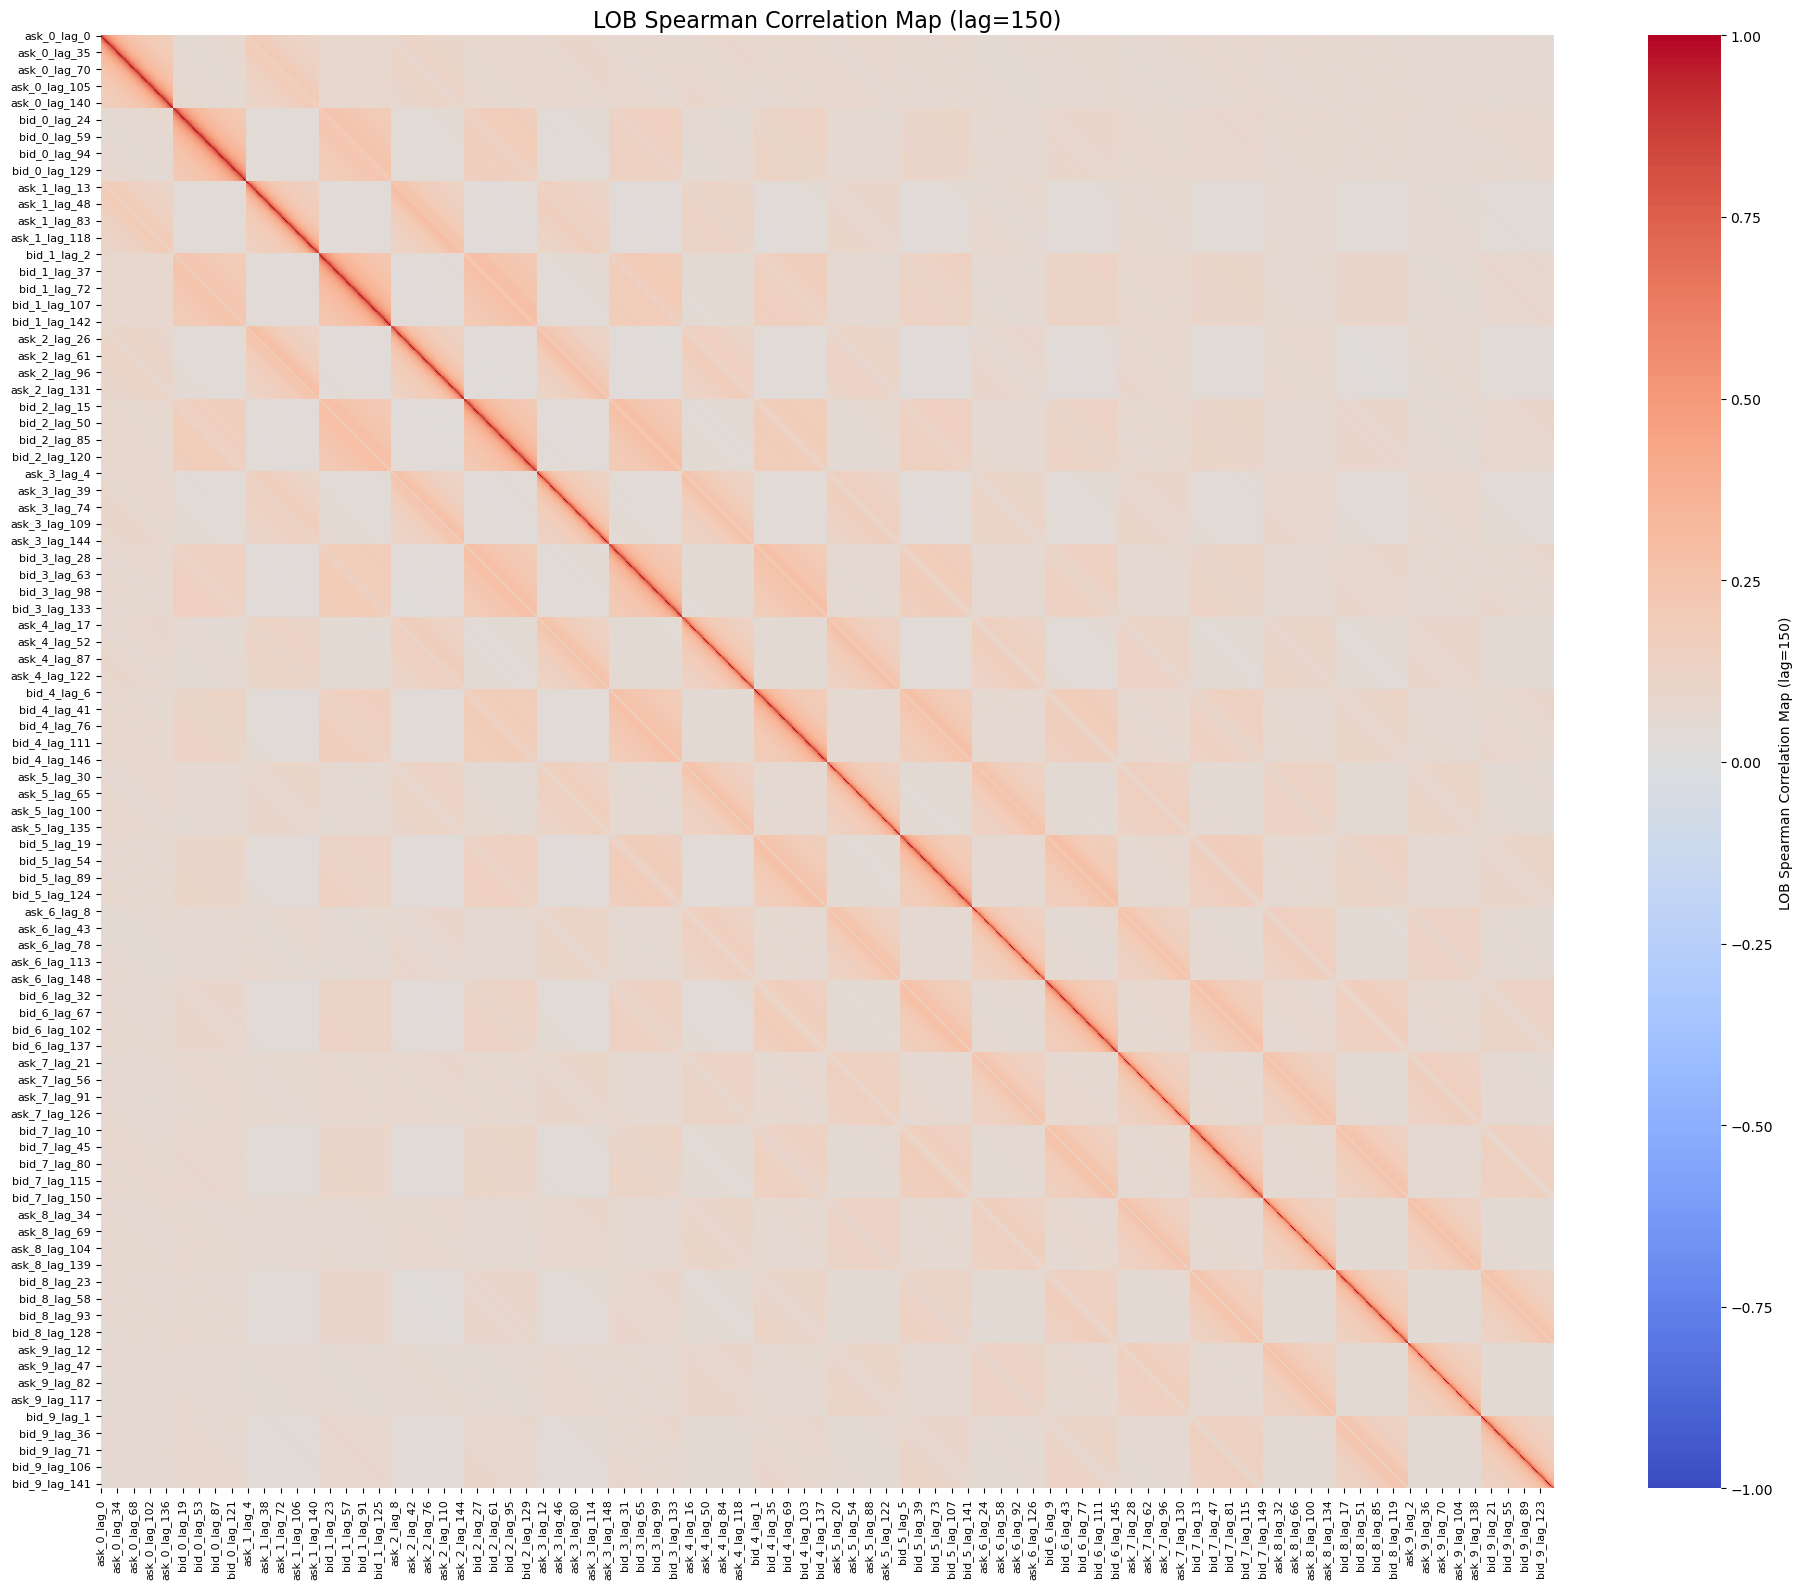


--- QUICK STATS ---
Pearson mean (off-diagonal) : 0.0496
Spearman mean (off-diagonal): 0.0991
NMI mean (off-diagonal) [bins=250] : 0.0563
NMI mean (off-diagonal) [bins=500] : 0.0770

MULTI-LAG + MULTI-BIN ANALYSIS COMPLETED

MAX_LAG = 150
  Pearson off-diagonal mean : 0.0496
  Spearman off-diagonal mean: 0.0991
  NMI off-diagonal mean [bins=250] : 0.0563
  NMI off-diagonal mean [bins=500] : 0.0770


In [2]:
# ============================================================
# UTILS - GENERAL
# ============================================================

def clear_gpu_memory():
    try:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass
    gc.collect()


def offdiag_mean(df: pd.DataFrame) -> float:
    arr = df.values
    idx = np.triu_indices_from(arr, k=1)
    vals = arr[idx]
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return float("nan")
    return float(vals.mean())


def quick_matrix_checks(df: pd.DataFrame, name: str):
    arr = df.values
    symmetric_error = np.nanmax(np.abs(arr - arr.T))
    diag_mean = np.nanmean(np.diag(arr))

    print(f"{name} diagonal mean      : {diag_mean:.6f}")
    print(f"{name} max symmetry error: {symmetric_error:.6e}")


def plot_heatmap(df: pd.DataFrame, title: str, cmap: str = "YlGnBu", vmin=None, vmax=None):
    plt.figure(figsize=(20, 16))
    sns.heatmap(
        df,
        annot=False,
        cmap=cmap,
        cbar_kws={"label": title},
        linewidths=0,
        square=True,
        vmin=vmin,
        vmax=vmax
    )
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def parse_feature_name(name: str):
    parts = name.split("_")
    side = parts[0]
    level = int(parts[1])
    lag = int(parts[3])
    base = f"{side}_{level}"
    return side, level, lag, base


# ============================================================
# UTILS - NMI
# ============================================================

def gpu_entropy_from_counts(counts: cp.ndarray, n_samples: int) -> cp.float32:
    probs = counts[counts > 0].astype(cp.float32) / cp.float32(n_samples)
    if probs.size == 0:
        return cp.float32(0.0)
    return -cp.sum(probs * cp.log(probs))


def gpu_nmi_discrete(x: cp.ndarray, y: cp.ndarray, n_bins: int) -> float:
    n = x.size
    if n == 0:
        return 0.0

    cx = cp.bincount(x, minlength=n_bins)
    cy = cp.bincount(y, minlength=n_bins)

    joint_idx = x * n_bins + y
    cxy = cp.bincount(joint_idx, minlength=n_bins * n_bins).reshape(n_bins, n_bins)

    hx = gpu_entropy_from_counts(cx, n)
    hy = gpu_entropy_from_counts(cy, n)

    if hx == 0.0 and hy == 0.0:
        return 1.0
    if hx == 0.0 or hy == 0.0:
        return 0.0

    px = cx.astype(cp.float32) / cp.float32(n)
    py = cy.astype(cp.float32) / cp.float32(n)
    pxy = cxy.astype(cp.float32) / cp.float32(n)

    nz = pxy > 0
    pxy_nz = pxy[nz]

    px_py = px[:, None] * py[None, :]
    denom = px_py[nz]

    mi = cp.sum(pxy_nz * cp.log(pxy_nz / denom))
    nmi = mi / ((hx + hy) / 2.0)

    return float(nmi)


def quantile_discretize_gpu(X: cp.ndarray, n_bins: int) -> cp.ndarray:
    n_rows, n_cols = X.shape
    X_disc = cp.empty((n_rows, n_cols), dtype=cp.int32)

    quantiles = cp.linspace(0, 1, n_bins + 1, dtype=cp.float32)

    for j in tqdm(range(n_cols), desc=f"Quantile discretization (bins={n_bins})"):
        col = X[:, j]
        edges = cp.quantile(col, quantiles)
        edges = cp.unique(edges)

        if edges.size <= 2:
            X_disc[:, j] = 0
            continue

        internal_edges = edges[1:-1]
        X_disc[:, j] = cp.digitize(col, internal_edges, right=False).astype(cp.int32)

    return X_disc


def build_nmi_similarity_matrix_gpu_full(X_disc: cp.ndarray, feature_names, n_bins: int) -> pd.DataFrame:
    n_features = X_disc.shape[1]
    sim = cp.empty((n_features, n_features), dtype=cp.float32)

    sim.fill(cp.nan)
    for i in range(n_features):
        sim[i, i] = 1.0

    total_pairs = n_features * (n_features - 1) // 2

    with tqdm(total=total_pairs, desc=f"Computing pairwise NMI FULL (bins={n_bins})") as pbar:
        for i in range(n_features):
            xi = X_disc[:, i]
            for j in range(i + 1, n_features):
                xj = X_disc[:, j]
                val = gpu_nmi_discrete(xi, xj, n_bins=n_bins)
                sim[i, j] = val
                sim[j, i] = val
                pbar.update(1)

    sim_cpu = cp.asnumpy(sim)
    return pd.DataFrame(sim_cpu, index=feature_names, columns=feature_names)


def build_nmi_similarity_matrix_gpu_relative_lag(
    X_disc: cp.ndarray,
    feature_names,
    base_feature_names,
    max_lag: int,
    n_bins: int
) -> pd.DataFrame:
    """
    Approximate NMI matrix using only:
      sim(base_i, base_j, delta_lag)
    and then reconstruct the full lagged feature-feature matrix.

    Assumption:
      similarity depends mainly on relative lag, not absolute lag index.
    """
    n_features = len(feature_names)
    feature_to_idx = {name: i for i, name in enumerate(feature_names)}

    # Parse metadata once
    meta = [parse_feature_name(f) for f in feature_names]

    # Precompute reduced map
    sim_map = {}

    total_reduced = len(base_feature_names) * len(base_feature_names) * (2 * max_lag + 1)

    with tqdm(total=total_reduced, desc=f"Computing reduced NMI map (bins={n_bins})") as pbar:
        for base_i in base_feature_names:
            for base_j in base_feature_names:
                for delta in range(-max_lag, max_lag + 1):
                    # canonical representative:
                    # if delta >= 0 -> compare base_i_lag_delta vs base_j_lag_0
                    # if delta < 0  -> compare base_i_lag_0 vs base_j_lag_-delta
                    lag_i = max(delta, 0)
                    lag_j = max(-delta, 0)

                    fi = f"{base_i}_lag_{lag_i}"
                    fj = f"{base_j}_lag_{lag_j}"

                    idx_i = feature_to_idx[fi]
                    idx_j = feature_to_idx[fj]

                    val = gpu_nmi_discrete(X_disc[:, idx_i], X_disc[:, idx_j], n_bins=n_bins)
                    sim_map[(base_i, base_j, delta)] = val
                    pbar.update(1)

    # Reconstruct full matrix
    sim = cp.empty((n_features, n_features), dtype=cp.float32)
    sim.fill(cp.nan)

    total_pairs = n_features * (n_features + 1) // 2
    with tqdm(total=total_pairs, desc=f"Reconstructing full NMI matrix (bins={n_bins})") as pbar:
        for i in range(n_features):
            side_i, level_i, lag_i, base_i = meta[i]
            sim[i, i] = 1.0
            pbar.update(1)

            for j in range(i + 1, n_features):
                side_j, level_j, lag_j, base_j = meta[j]
                delta = lag_i - lag_j
                val = sim_map[(base_i, base_j, delta)]
                sim[i, j] = val
                sim[j, i] = val
                pbar.update(1)

    sim_cpu = cp.asnumpy(sim)
    return pd.DataFrame(sim_cpu, index=feature_names, columns=feature_names)


# ============================================================
# UTILS - SPEARMAN / CORRELATION
# ============================================================

def rank_columns_gpu(X: cp.ndarray) -> cp.ndarray:
    n_rows, n_cols = X.shape
    ranks = cp.empty_like(X, dtype=cp.float32)

    for j in tqdm(range(n_cols), desc="Ranking columns for Spearman"):
        order = cp.argsort(X[:, j])
        ranks[order, j] = cp.arange(n_rows, dtype=cp.float32)

    return ranks


def corrcoef_gpu_to_pandas(X: cp.ndarray, feature_names) -> pd.DataFrame:
    corr = cp.corrcoef(X, rowvar=False)
    corr_cpu = cp.asnumpy(corr)
    return pd.DataFrame(corr_cpu, index=feature_names, columns=feature_names)


# ============================================================
# UTILS - MEMORY-EFFICIENT LAGGED MATRIX
# ============================================================

def build_lagged_cudf_ordered_memory_efficient(df_base: cudf.DataFrame, max_lag: int) -> cudf.DataFrame:
    n = len(df_base)
    if max_lag >= n:
        raise ValueError(f"max_lag={max_lag} must be smaller than number of rows={n}")

    ordered_series = []

    for base_col in df_base.columns:
        for lag in range(max_lag + 1):
            start = max_lag - lag
            stop = n - lag
            col = df_base[base_col].iloc[start:stop].reset_index(drop=True)
            col.name = f"{base_col}_lag_{lag}"
            ordered_series.append(col)

    df_lagged = cudf.concat(ordered_series, axis=1)
    return df_lagged


# ============================================================
# LOAD CSV ON GPU
# ============================================================

print("Loading CSV on GPU with cuDF...")

if NROWS is not None:
    df_10 = cudf.read_csv(CSV_PATH, header=None, nrows=NROWS)
else:
    df_10 = cudf.read_csv(CSV_PATH, header=None)

print(f"Loaded shape: {df_10.shape}")


# ============================================================
# EXTRACT ASK/BID SIZE COLUMNS
# ============================================================

print("Extracting size columns...")

ask_size_indices = [4 * i + 1 for i in range(NUM_LEVELS)]
bid_size_indices = [4 * i + 3 for i in range(NUM_LEVELS)]

selected_indices = []
selected_names = []

for i in range(NUM_LEVELS):
    selected_indices.append(ask_size_indices[i])
    selected_names.append(f"ask_{i}")

    selected_indices.append(bid_size_indices[i])
    selected_names.append(f"bid_{i}")

df_sizes = df_10.iloc[:, selected_indices]
df_sizes.columns = selected_names

print(f"df_sizes shape: {df_sizes.shape}")
print("Base feature order:")
print(selected_names)


# ============================================================
# CORE ANALYSIS FOR A GIVEN LAG
# ============================================================

def run_full_analysis_for_lag(df_sizes: cudf.DataFrame, max_lag: int, n_bins_list):
    print("\n" + "=" * 70)
    print(f"RUNNING ANALYSIS FOR MAX_LAG = {max_lag}")
    print("=" * 70)

    n_rows = len(df_sizes)
    if max_lag >= n_rows:
        raise ValueError(f"max_lag={max_lag} must be smaller than number of rows={n_rows}")

    expected_n_features = 2 * NUM_LEVELS * (max_lag + 1)
    if expected_n_features > MAX_FEATURES_HARD_LIMIT:
        raise MemoryError(
            f"Expected features = {expected_n_features}, which exceeds the hard safety limit "
            f"({MAX_FEATURES_HARD_LIMIT}). Reduce max_lag."
        )

    print("Building lagged dataframe (memory-efficient)...")
    df_lagged = build_lagged_cudf_ordered_memory_efficient(df_sizes, max_lag)
    feature_names = list(df_lagged.columns)
    base_feature_names = list(df_sizes.columns)

    print(f"df_lagged shape: {df_lagged.shape}")
    print(f"Number of features: {len(feature_names)}")
    print("First 12 feature names:")
    print(feature_names[:12])
    print(f"Expected number of features: {expected_n_features}")

    print("Converting lagged matrix to CuPy array...")
    dtype = cp.float32 if USE_FLOAT32 else cp.float64
    X = df_lagged.to_cupy().astype(dtype, copy=False)

    n_samples, n_features = X.shape
    print(f"X shape: {X.shape}")

    del df_lagged
    clear_gpu_memory()

    # --------------------------------------------------------
    # PEARSON
    # --------------------------------------------------------
    print("Computing Pearson correlation matrix on GPU...")
    pearson_df = corrcoef_gpu_to_pandas(X, feature_names)
    print("Pearson done.")
    quick_matrix_checks(pearson_df, "Pearson")

    # --------------------------------------------------------
    # SPEARMAN
    # --------------------------------------------------------
    print("Computing Spearman correlation matrix on GPU...")
    X_rank = rank_columns_gpu(X)
    spearman_df = corrcoef_gpu_to_pandas(X_rank, feature_names)
    print("Spearman done.")
    quick_matrix_checks(spearman_df, "Spearman")

    del X_rank
    clear_gpu_memory()

    # --------------------------------------------------------
    # NMI FOR MULTIPLE BIN COUNTS
    # --------------------------------------------------------
    nmi_results = {}

    if n_features <= MAX_FEATURES_FOR_NMI:
        for n_bins in n_bins_list:
            print("\n" + "-" * 60)
            print(f"Running NMI with n_bins = {n_bins}")
            print("-" * 60)

            print("Discretizing for NMI on GPU...")
            X_disc = quantile_discretize_gpu(X, n_bins=n_bins)

            if USE_RELATIVE_LAG_NMI:
                print("Computing NMI similarity matrix on GPU (relative-lag approximation)...")
                nmi_df = build_nmi_similarity_matrix_gpu_relative_lag(
                    X_disc=X_disc,
                    feature_names=feature_names,
                    base_feature_names=base_feature_names,
                    max_lag=max_lag,
                    n_bins=n_bins
                )
            else:
                print("Computing NMI similarity matrix on GPU (full pairwise)...")
                nmi_df = build_nmi_similarity_matrix_gpu_full(
                    X_disc=X_disc,
                    feature_names=feature_names,
                    n_bins=n_bins
                )

            print(f"NMI done for bins={n_bins}.")
            quick_matrix_checks(nmi_df, f"NMI (bins={n_bins})")
            print(f"NMI mean (off-diagonal): {offdiag_mean(nmi_df):.4f}")

            if SAVE_CSV:
                suffix = "_rellag" if USE_RELATIVE_LAG_NMI else ""
                nmi_path = f"lob_similarity_nmi{suffix}_lag{max_lag}_bins{n_bins}.csv"
                nmi_df.to_csv(nmi_path, index=True)
                print(f"Saved NMI -> {os.path.abspath(nmi_path)}")

            if PLOT_HEATMAPS and n_features <= MAX_FEATURES_FOR_PLOT:
                print(f"Plotting NMI heatmap for bins={n_bins}...")
                plot_heatmap(
                    nmi_df,
                    f"LOB NMI Map (lag={max_lag}, bins={n_bins})",
                    cmap="YlGnBu",
                    vmin=0,
                    vmax=1
                )

            nmi_results[n_bins] = nmi_df

            del X_disc
            clear_gpu_memory()
    else:
        print(
            f"Skipping all NMI runs: number of features ({n_features}) exceeds "
            f"MAX_FEATURES_FOR_NMI ({MAX_FEATURES_FOR_NMI})."
        )

    del X
    clear_gpu_memory()

    # --------------------------------------------------------
    # SAVE PEARSON / SPEARMAN
    # --------------------------------------------------------
    if SAVE_CSV:
        pearson_path = f"lob_similarity_pearson_lag{max_lag}.csv"
        spearman_path = f"lob_similarity_spearman_lag{max_lag}.csv"

        pearson_df.to_csv(pearson_path, index=True)
        spearman_df.to_csv(spearman_path, index=True)

        print("\nSaved files:")
        print(f"Pearson  -> {os.path.abspath(pearson_path)}")
        print(f"Spearman -> {os.path.abspath(spearman_path)}")

    # --------------------------------------------------------
    # PLOT PEARSON / SPEARMAN
    # --------------------------------------------------------
    if PLOT_HEATMAPS:
        if n_features <= MAX_FEATURES_FOR_PLOT:
            print("\nPlotting Pearson...")
            plot_heatmap(
                pearson_df,
                f"LOB Pearson Correlation Map (lag={max_lag})",
                cmap="coolwarm",
                vmin=-1,
                vmax=1
            )

            print("Plotting Spearman...")
            plot_heatmap(
                spearman_df,
                f"LOB Spearman Correlation Map (lag={max_lag})",
                cmap="coolwarm",
                vmin=-1,
                vmax=1
            )
        else:
            print(
                f"Skipping plots: number of features ({n_features}) exceeds "
                f"MAX_FEATURES_FOR_PLOT ({MAX_FEATURES_FOR_PLOT})."
            )

    # --------------------------------------------------------
    # QUICK SUMMARY
    # --------------------------------------------------------
    print("\n--- QUICK STATS ---")
    print(f"Pearson mean (off-diagonal) : {offdiag_mean(pearson_df):.4f}")
    print(f"Spearman mean (off-diagonal): {offdiag_mean(spearman_df):.4f}")
    for n_bins, nmi_df in nmi_results.items():
        print(f"NMI mean (off-diagonal) [bins={n_bins}] : {offdiag_mean(nmi_df):.4f}")

    return {
        "pearson": pearson_df,
        "spearman": spearman_df,
        "nmi_by_bins": nmi_results,
        "feature_names": feature_names
    }


# ============================================================
# RUN MULTI-LAG ANALYSIS
# ============================================================

results = {}

for lag in LAG_LIST:
    try:
        results[lag] = run_full_analysis_for_lag(df_sizes, lag, N_BINS_LIST)
    except Exception as e:
        print(f"\n[ERROR] Failed for lag={lag}: {type(e).__name__}: {e}")
        results[lag] = {
            "pearson": None,
            "spearman": None,
            "nmi_by_bins": {},
            "feature_names": None,
            "error": str(e)
        }
    finally:
        clear_gpu_memory()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MULTI-LAG + MULTI-BIN ANALYSIS COMPLETED")
print("=" * 70)

for lag in LAG_LIST:
    print(f"\nMAX_LAG = {lag}")

    if results[lag]["pearson"] is None:
        print(f"  Failed: {results[lag].get('error', 'unknown error')}")
        continue

    pearson_df = results[lag]["pearson"]
    spearman_df = results[lag]["spearman"]
    nmi_by_bins = results[lag]["nmi_by_bins"]

    print(f"  Pearson off-diagonal mean : {offdiag_mean(pearson_df):.4f}")
    print(f"  Spearman off-diagonal mean: {offdiag_mean(spearman_df):.4f}")

    if len(nmi_by_bins) == 0:
        print("  NMI off-diagonal mean     : skipped")
    else:
        for n_bins in N_BINS_LIST:
            if n_bins in nmi_by_bins:
                print(f"  NMI off-diagonal mean [bins={n_bins}] : {offdiag_mean(nmi_by_bins[n_bins]):.4f}")

---
---
---

Loaded and aligned matrices:
  Full   shape: (1420, 1420)
  Approx shape: (1420, 1420)

GLOBAL ERROR METRICS
                                metric         value
0                           n_features  1.420000e+03
1                      n_offdiag_pairs  1.007490e+06
2                  mean_absolute_error  9.533710e-05
3                median_absolute_error  4.411500e-05
4                   max_absolute_error  2.692100e-03
5                                 rmse  1.564995e-04
6                    mean_signed_error  1.374101e-05
7                  mean_relative_error  1.788227e-03
8                median_relative_error  8.339616e-04
9   offdiag_correlation_full_vs_approx  9.999962e-01
10                   full_offdiag_mean  6.209018e-02
11                 approx_offdiag_mean  6.210392e-02

Saved files:
  Signed error matrix  -> ./nmi_error_signed.csv
  Absolute error matrix-> ./nmi_error_absolute.csv
  Relative error matrix-> ./nmi_error_relative.csv
  Metrics summary      -> ./nmi_error

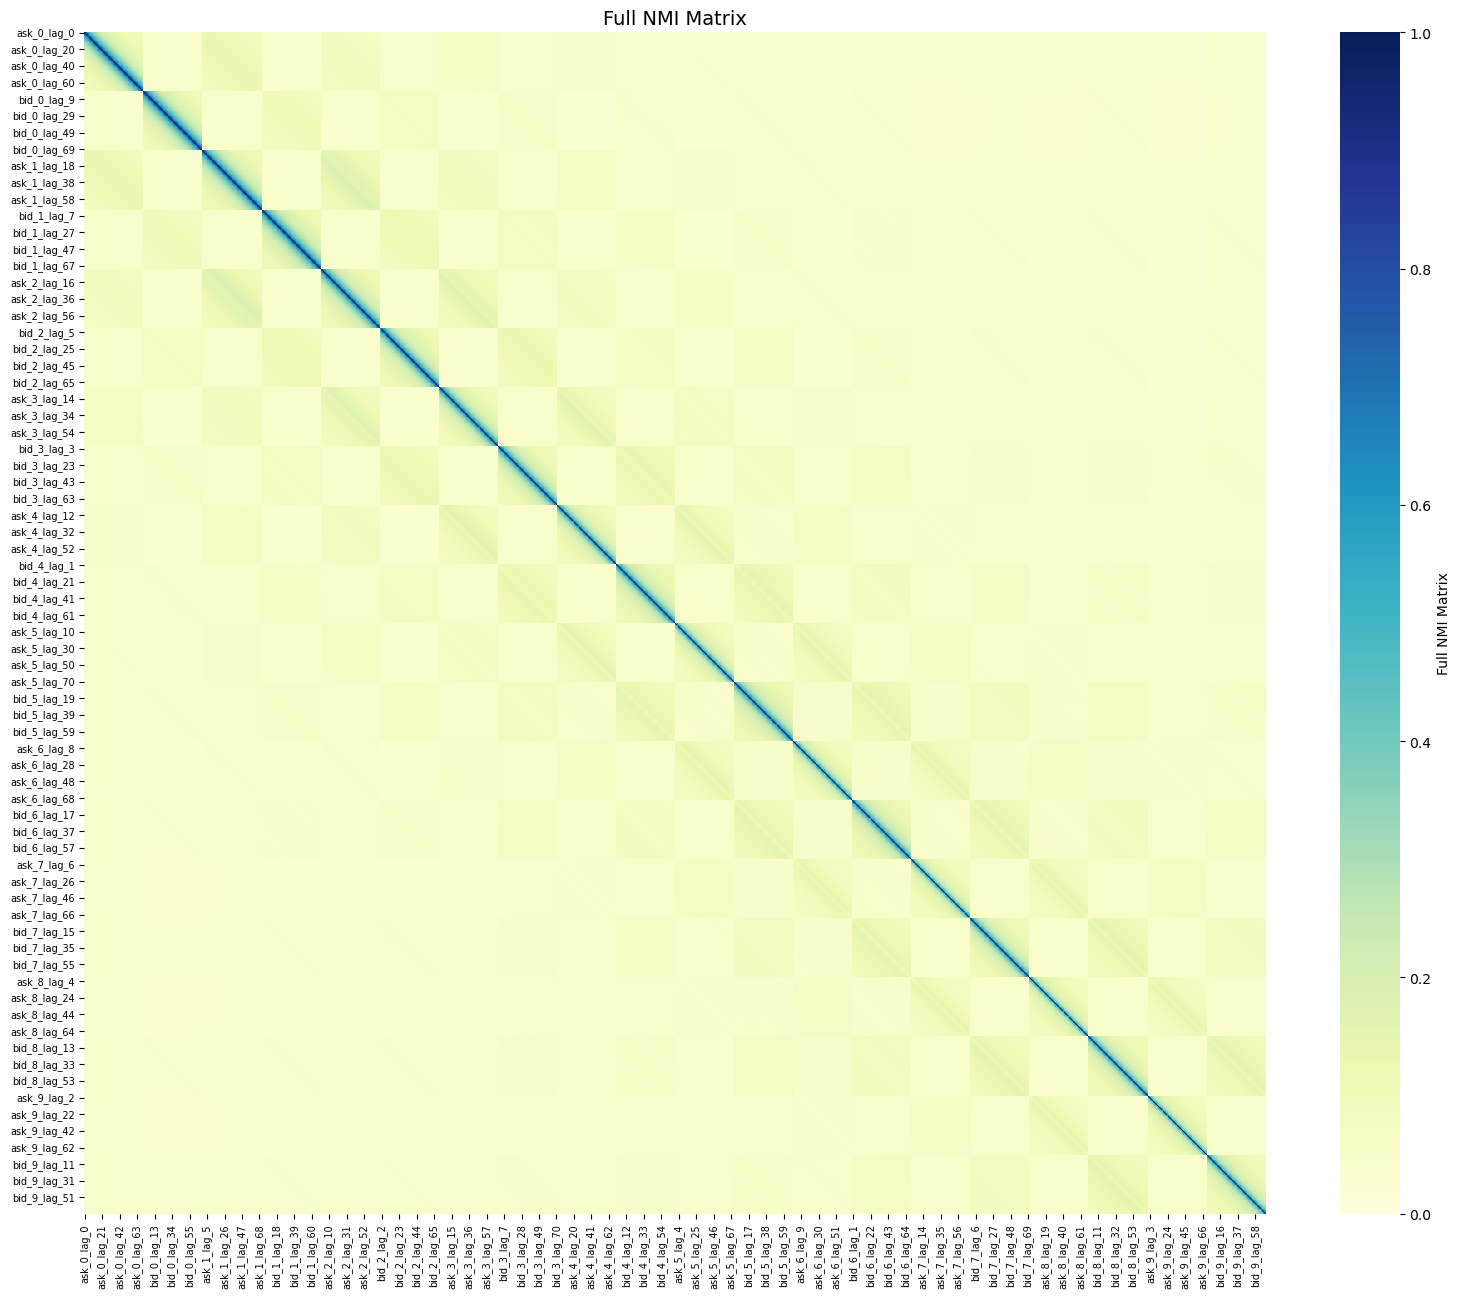

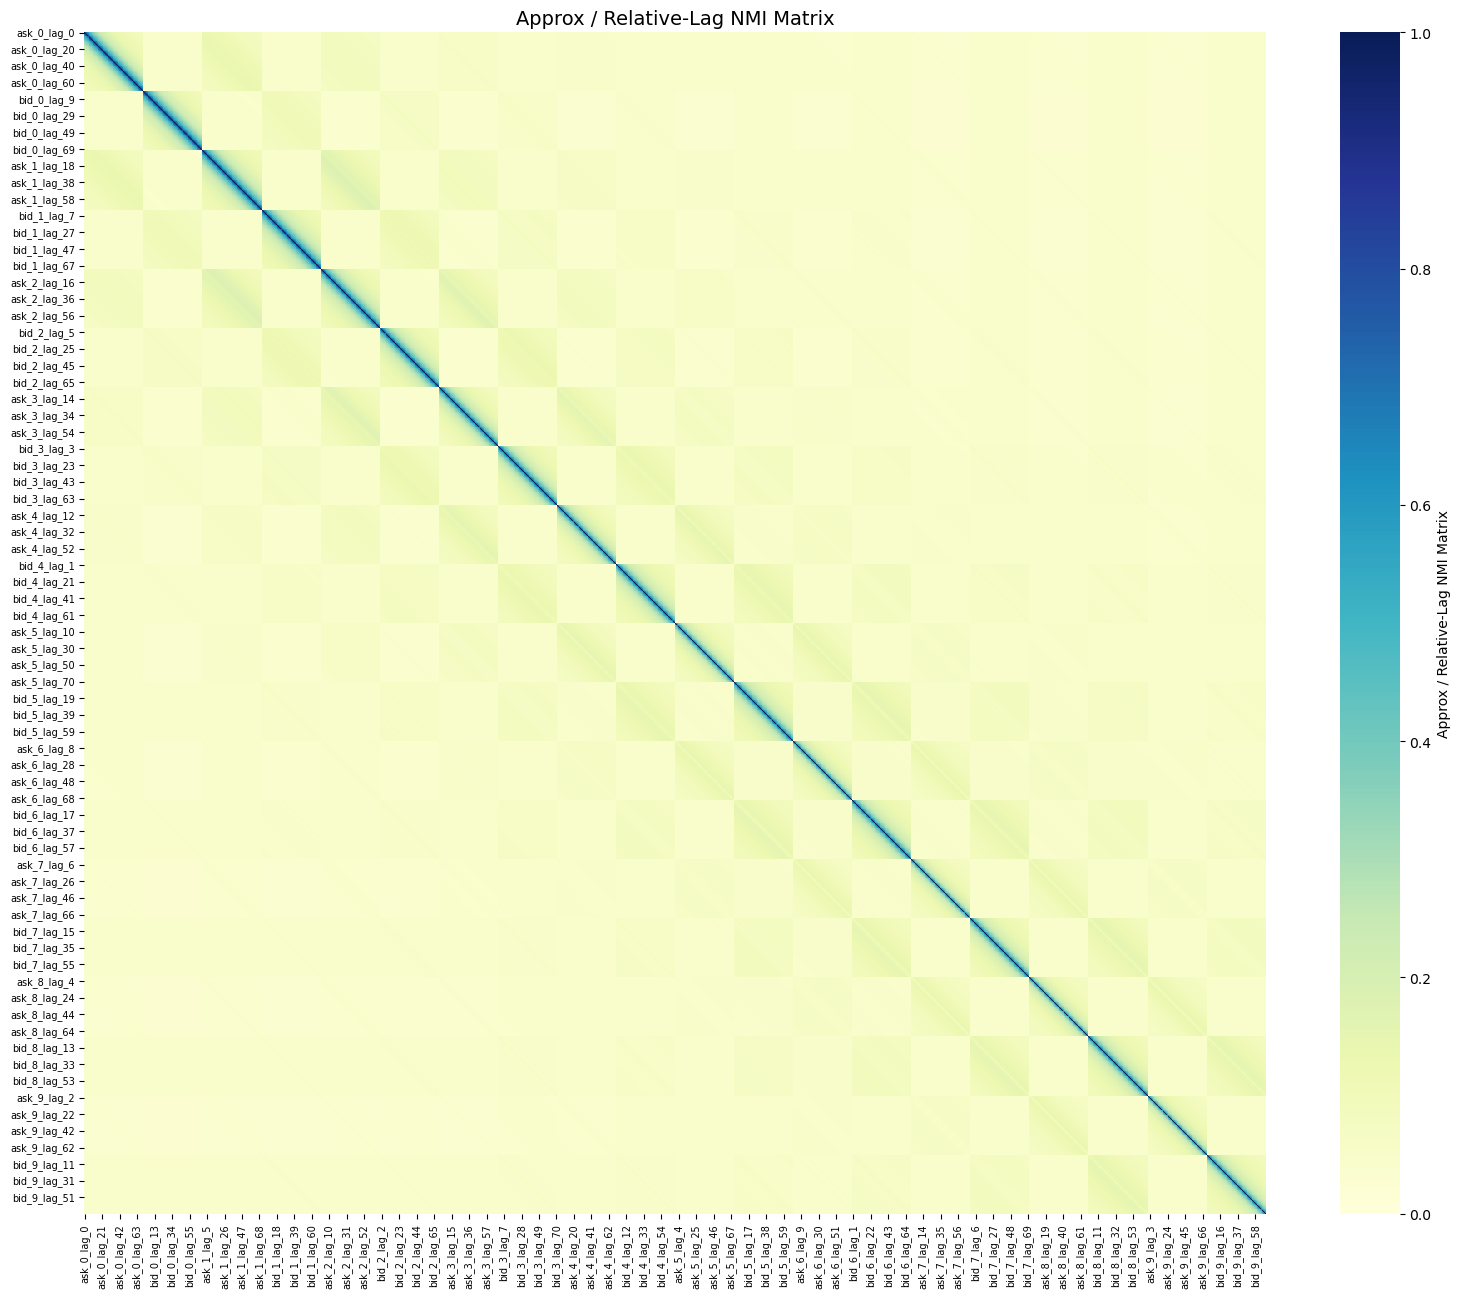

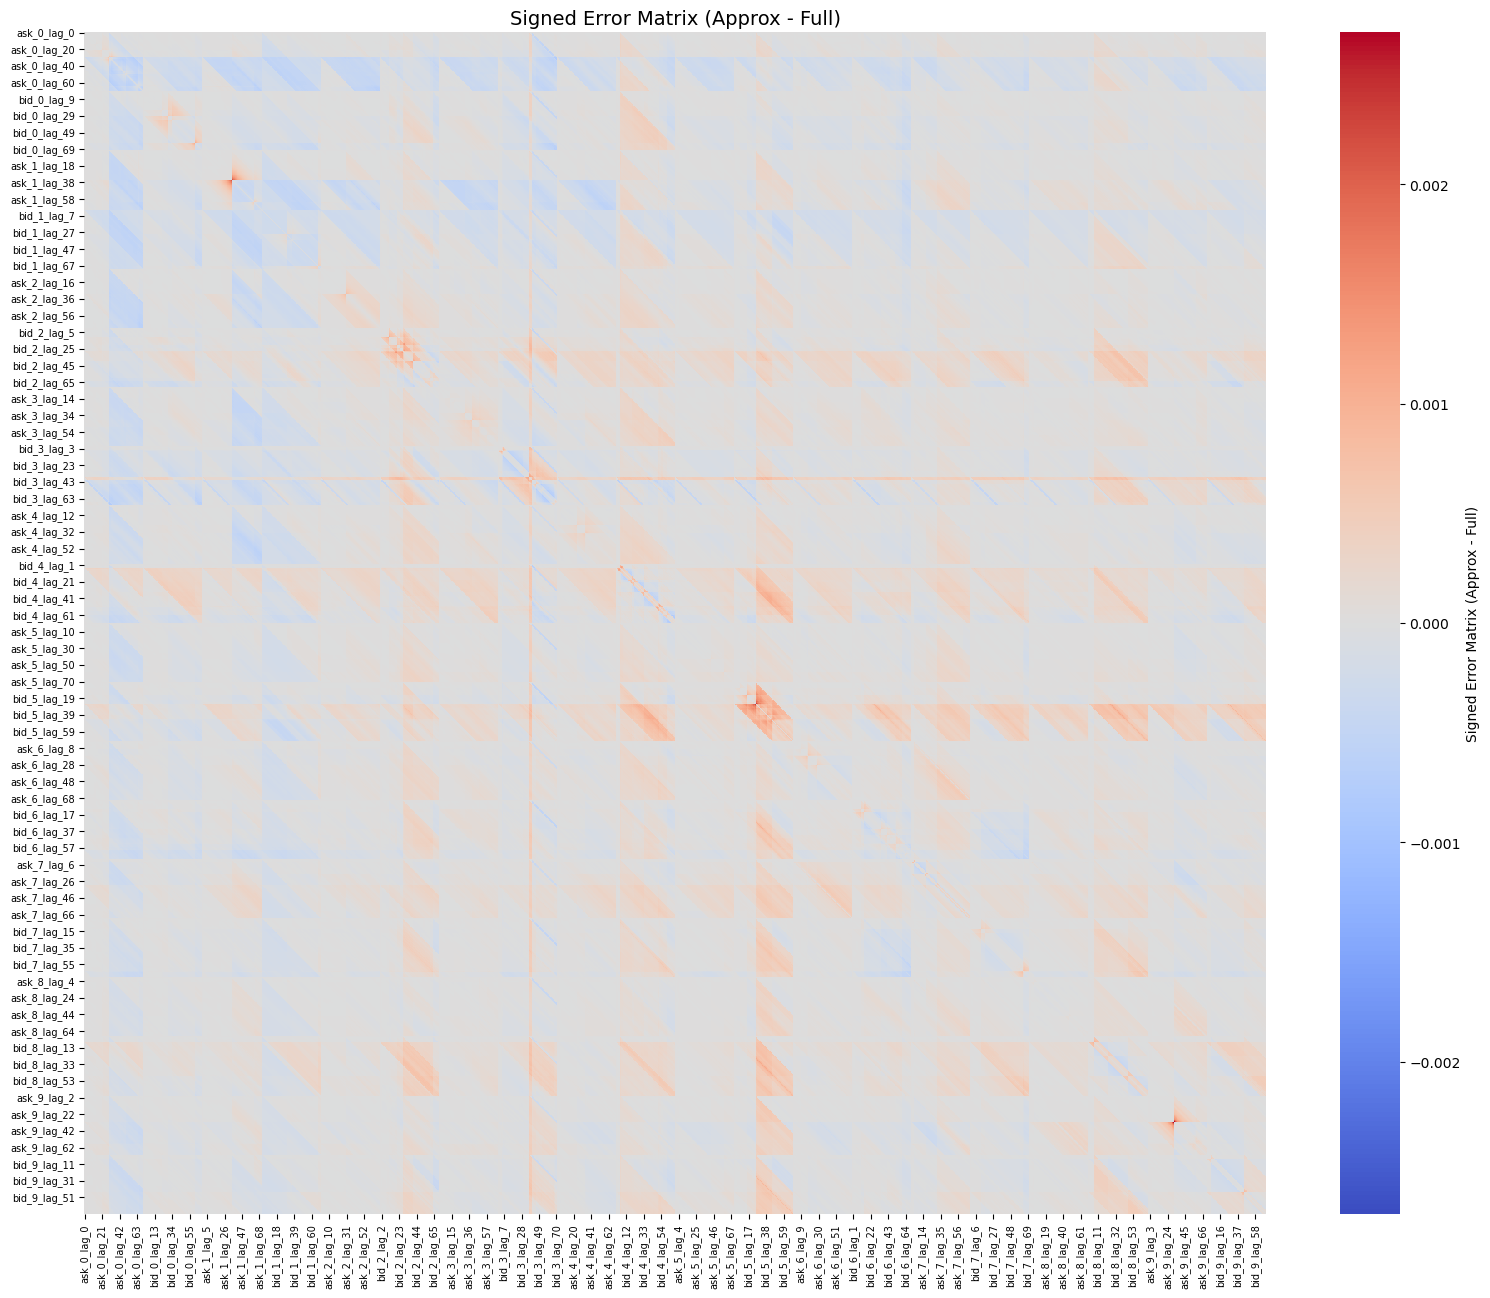

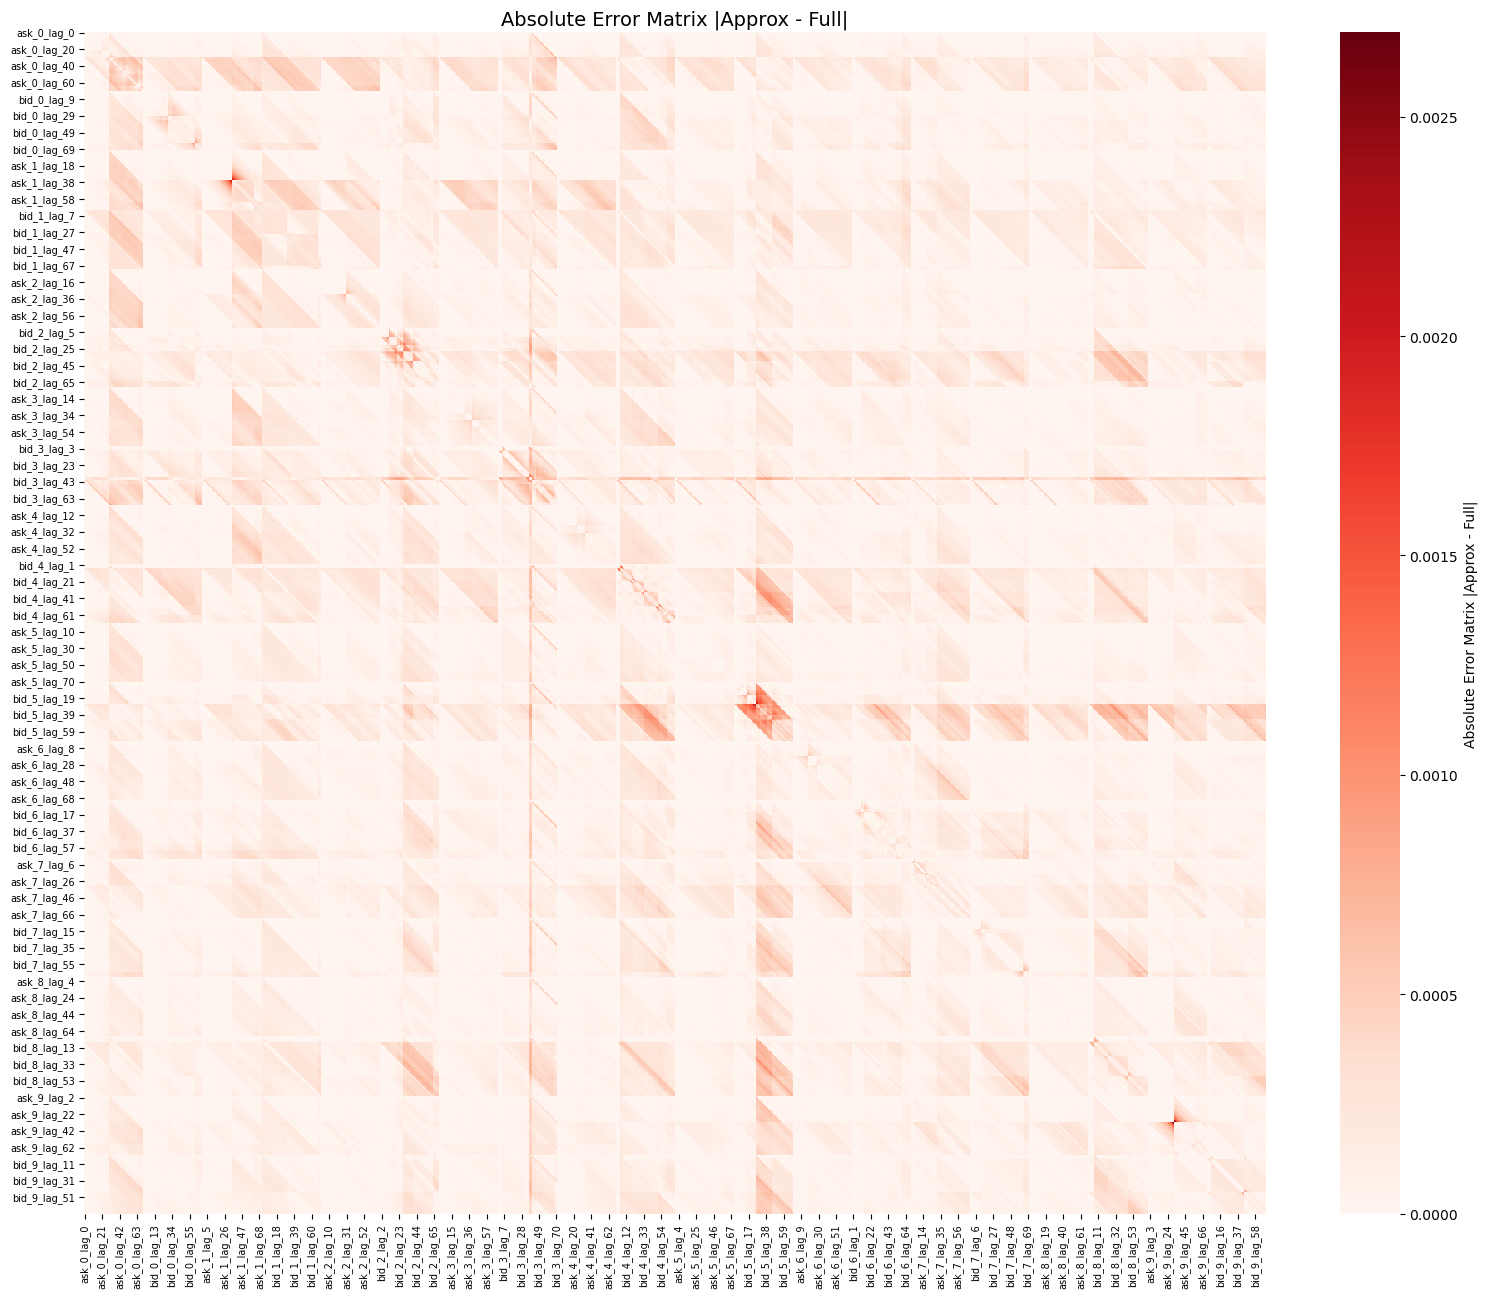

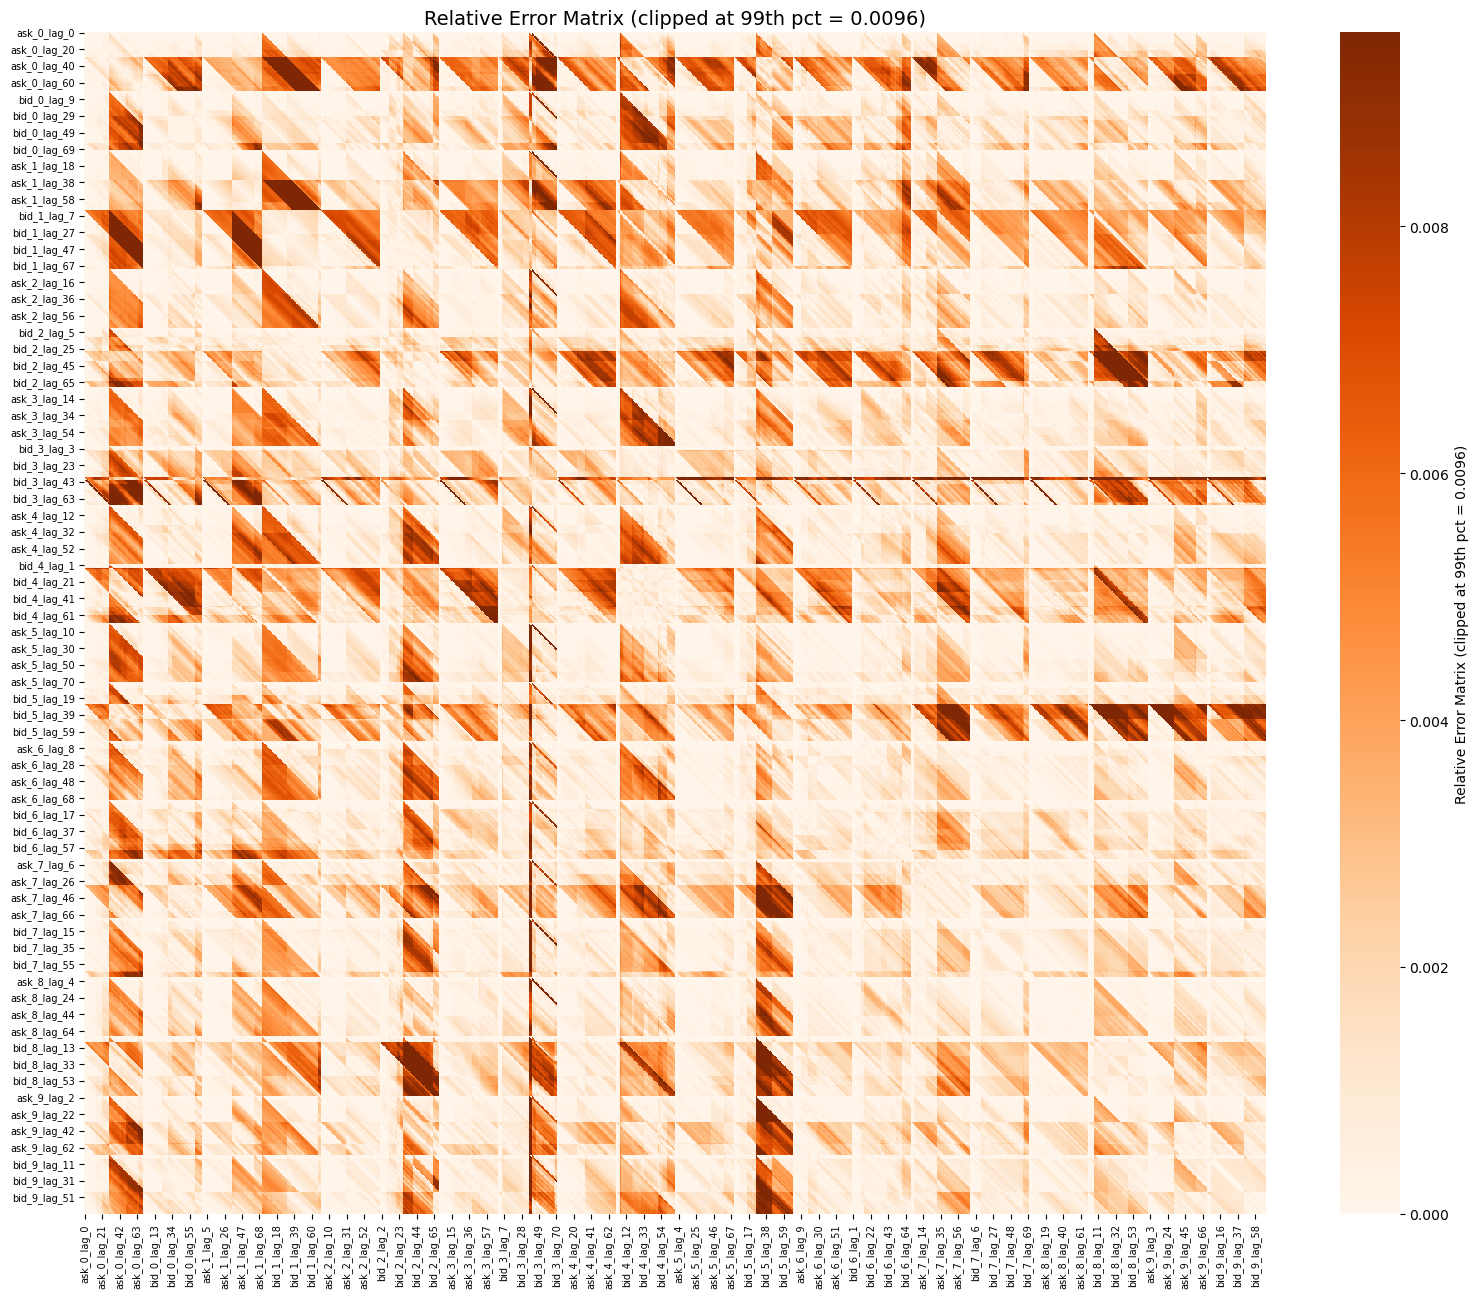

In [5]:
# # ============================================================
# # COMPARE FULL NMI VS RELATIVE-LAG APPROXIMATION
# # Reads two CSV similarity matrices, computes error matrices,
# # summary metrics, and optional plots.
# # ============================================================

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns


# # ============================================================
# # CONFIG
# # ============================================================

# FULL_CSV_PATH = "./lob_similarity_nmi_lag70_bins250.csv"
# APPROX_CSV_PATH = "./lob_similarity_nmi_rellag_lag70_bins250.csv"

# SAVE_ERROR_CSV = True
# PLOT_HEATMAPS = True

# OUTDIR = "."
# SIGNED_ERROR_CSV = "nmi_error_signed.csv"
# ABS_ERROR_CSV = "nmi_error_absolute.csv"
# REL_ERROR_CSV = "nmi_error_relative.csv"


# # ============================================================
# # UTILS
# # ============================================================

# def load_similarity_csv(path: str) -> pd.DataFrame:
#     """
#     Load square similarity matrix from CSV.
#     Assumes first column is index.
#     """
#     df = pd.read_csv(path, index_col=0)
#     df.columns = [str(c).strip() for c in df.columns]
#     df.index = [str(i).strip() for i in df.index]

#     # reorder columns to index if same label set
#     if set(df.index) != set(df.columns):
#         raise ValueError(
#             f"Index/column labels mismatch in file: {path}\n"
#             f"Index size={len(df.index)}, columns size={len(df.columns)}"
#         )

#     df = df.loc[df.index, df.index]
#     return df


# def align_two_similarity_matrices(df1: pd.DataFrame, df2: pd.DataFrame):
#     """
#     Keep only common labels and align both matrices to same order.
#     """
#     common = [x for x in df1.index if x in df2.index]

#     if len(common) == 0:
#         raise ValueError("No common labels found between matrices.")

#     df1_aligned = df1.loc[common, common].copy()
#     df2_aligned = df2.loc[common, common].copy()

#     return df1_aligned, df2_aligned


# def upper_triangle_values(arr: np.ndarray, k: int = 1) -> np.ndarray:
#     idx = np.triu_indices_from(arr, k=k)
#     vals = arr[idx]
#     vals = vals[~np.isnan(vals)]
#     return vals


# def safe_relative_error(full_arr: np.ndarray, approx_arr: np.ndarray, eps: float = 1e-12) -> np.ndarray:
#     """
#     Relative error = |approx - full| / max(|full|, eps)
#     """
#     denom = np.maximum(np.abs(full_arr), eps)
#     rel = np.abs(approx_arr - full_arr) / denom
#     return rel


# def plot_heatmap(df: pd.DataFrame, title: str, cmap: str = "YlGnBu", center=None, vmin=None, vmax=None):
#     plt.figure(figsize=(16, 13))
#     sns.heatmap(
#         df,
#         annot=False,
#         cmap=cmap,
#         linewidths=0,
#         square=True,
#         center=center,
#         vmin=vmin,
#         vmax=vmax,
#         cbar_kws={"label": title}
#     )
#     plt.title(title, fontsize=14)
#     plt.xticks(rotation=90, fontsize=7)
#     plt.yticks(fontsize=7)
#     plt.tight_layout()
#     plt.show()


# # ============================================================
# # LOAD AND ALIGN
# # ============================================================

# full_df = load_similarity_csv(FULL_CSV_PATH)
# approx_df = load_similarity_csv(APPROX_CSV_PATH)

# full_df, approx_df = align_two_similarity_matrices(full_df, approx_df)

# print("Loaded and aligned matrices:")
# print(f"  Full   shape: {full_df.shape}")
# print(f"  Approx shape: {approx_df.shape}")


# # ============================================================
# # COMPUTE ERROR MATRICES
# # ============================================================

# full_arr = full_df.values.astype(float)
# approx_arr = approx_df.values.astype(float)

# signed_error_arr = approx_arr - full_arr
# abs_error_arr = np.abs(signed_error_arr)
# rel_error_arr = safe_relative_error(full_arr, approx_arr)

# signed_error_df = pd.DataFrame(
#     signed_error_arr,
#     index=full_df.index,
#     columns=full_df.columns
# )

# abs_error_df = pd.DataFrame(
#     abs_error_arr,
#     index=full_df.index,
#     columns=full_df.columns
# )

# rel_error_df = pd.DataFrame(
#     rel_error_arr,
#     index=full_df.index,
#     columns=full_df.columns
# )


# # ============================================================
# # GLOBAL METRICS
# # ============================================================

# # Off-diagonal only: the interesting part
# full_off = upper_triangle_values(full_arr, k=1)
# approx_off = upper_triangle_values(approx_arr, k=1)
# signed_off = upper_triangle_values(signed_error_arr, k=1)
# abs_off = upper_triangle_values(abs_error_arr, k=1)
# rel_off = upper_triangle_values(rel_error_arr, k=1)

# mae = float(np.mean(abs_off))
# mse = float(np.mean((approx_off - full_off) ** 2))
# rmse = float(np.sqrt(mse))
# max_abs = float(np.max(abs_off))
# mean_signed = float(np.mean(signed_off))
# median_abs = float(np.median(abs_off))
# mean_rel = float(np.mean(rel_off))
# median_rel = float(np.median(rel_off))

# if np.std(full_off) > 0 and np.std(approx_off) > 0:
#     offdiag_corr = float(np.corrcoef(full_off, approx_off)[0, 1])
# else:
#     offdiag_corr = np.nan

# metrics_df = pd.DataFrame({
#     "metric": [
#         "n_features",
#         "n_offdiag_pairs",
#         "mean_absolute_error",
#         "median_absolute_error",
#         "max_absolute_error",
#         "rmse",
#         "mean_signed_error",
#         "mean_relative_error",
#         "median_relative_error",
#         "offdiag_correlation_full_vs_approx",
#         "full_offdiag_mean",
#         "approx_offdiag_mean"
#     ],
#     "value": [
#         full_df.shape[0],
#         len(full_off),
#         mae,
#         median_abs,
#         max_abs,
#         rmse,
#         mean_signed,
#         mean_rel,
#         median_rel,
#         offdiag_corr,
#         float(np.mean(full_off)),
#         float(np.mean(approx_off))
#     ]
# })

# print("\nGLOBAL ERROR METRICS")
# print(metrics_df)


# # ============================================================
# # SAVE CSVs
# # ============================================================

# if SAVE_ERROR_CSV:
#     signed_error_path = os.path.join(OUTDIR, SIGNED_ERROR_CSV)
#     abs_error_path = os.path.join(OUTDIR, ABS_ERROR_CSV)
#     rel_error_path = os.path.join(OUTDIR, REL_ERROR_CSV)
#     metrics_path = os.path.join(OUTDIR, "nmi_error_metrics_summary.csv")

#     signed_error_df.to_csv(signed_error_path, index=True)
#     abs_error_df.to_csv(abs_error_path, index=True)
#     rel_error_df.to_csv(rel_error_path, index=True)
#     metrics_df.to_csv(metrics_path, index=False)

#     print("\nSaved files:")
#     print(f"  Signed error matrix  -> {signed_error_path}")
#     print(f"  Absolute error matrix-> {abs_error_path}")
#     print(f"  Relative error matrix-> {rel_error_path}")
#     print(f"  Metrics summary      -> {metrics_path}")


# # ============================================================
# # OPTIONAL PLOTS
# # ============================================================

# if PLOT_HEATMAPS:
#     plot_heatmap(full_df, "Full NMI Matrix", cmap="YlGnBu", vmin=0, vmax=1)
#     plot_heatmap(approx_df, "Approx / Relative-Lag NMI Matrix", cmap="YlGnBu", vmin=0, vmax=1)

#     # signed error: diverging colormap
#     max_signed = np.nanmax(np.abs(signed_error_arr))
#     plot_heatmap(
#         signed_error_df,
#         "Signed Error Matrix (Approx - Full)",
#         cmap="coolwarm",
#         center=0,
#         vmin=-max_signed,
#         vmax=max_signed
#     )

#     # absolute error
#     plot_heatmap(
#         abs_error_df,
#         "Absolute Error Matrix |Approx - Full|",
#         cmap="Reds",
#         vmin=0,
#         vmax=np.nanmax(abs_error_arr)
#     )

#     # relative error can explode on tiny denominators; clip for readability
#     rel_clip = np.nanpercentile(rel_off, 99)
#     rel_plot_df = rel_error_df.clip(upper=rel_clip)

#     plot_heatmap(
#         rel_plot_df,
#         f"Relative Error Matrix (clipped at 99th pct = {rel_clip:.4f})",
#         cmap="Oranges",
#         vmin=0,
#         vmax=rel_clip
#     )

In [7]:
# ============================================================
# STRUCTURAL ANALYSIS FROM SAVED CSV FILES
# CLEAN NOTEBOOK VERSION: ONLY FINAL TABLES
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# CONFIG
# ============================================================

LAG_LIST = [70]
N_BINS_LIST = [250]

# folder where CSV files were saved; use "." if they are in the current folder
CSV_DIR = "."

SAVE_SUMMARY_CSV = True
SUMMARY_CSV_NAME = "lob_structural_analysis_summary_L70_B250.csv"


# ============================================================
# UTILS
# ============================================================

def parse_feature_name(name):
    """
    Extract (side, level, lag) from feature name.
    Example: 'ask_3_lag_2' -> ('ask', 3, 2)
    """
    parts = name.split("_")
    side = parts[0]
    level = int(parts[1])
    lag = int(parts[3])
    return side, level, lag


def load_similarity_csv(path: str) -> pd.DataFrame:
    """
    Load a saved similarity matrix CSV.
    Assumes first column contains row labels / index.
    """
    df = pd.read_csv(path, index_col=0)

    df.columns = [str(c).strip() for c in df.columns]
    df.index = [str(i).strip() for i in df.index]

    if list(df.index) != list(df.columns):
        missing_in_cols = [x for x in df.index if x not in df.columns]
        missing_in_idx = [x for x in df.columns if x not in df.index]

        if len(missing_in_cols) == 0 and len(missing_in_idx) == 0:
            df = df.loc[df.index, df.index]
        else:
            raise ValueError(
                f"Index/column mismatch in file: {path}\n"
                f"Missing in columns: {missing_in_cols[:5]}\n"
                f"Missing in index: {missing_in_idx[:5]}"
            )

    return df


def analyze_structure_summary(sim_df: pd.DataFrame) -> dict:
    """
    Compute structural summary statistics only.
    No printing, no raw arrays returned.
    """
    feature_names = list(sim_df.columns)
    n = len(feature_names)

    meta = [parse_feature_name(f) for f in feature_names]

    ask_ask = []
    bid_bid = []
    ask_bid = []

    same_level = []
    diff_level = []

    same_lag = []
    diff_lag = []

    same_node_diff_lag = []

    for i in range(n):
        for j in range(i + 1, n):
            val = sim_df.iloc[i, j]

            side_i, level_i, lag_i = meta[i]
            side_j, level_j, lag_j = meta[j]

            if side_i == "ask" and side_j == "ask":
                ask_ask.append(val)
            elif side_i == "bid" and side_j == "bid":
                bid_bid.append(val)
            else:
                ask_bid.append(val)

            if level_i == level_j:
                same_level.append(val)
            else:
                diff_level.append(val)

            if lag_i == lag_j:
                same_lag.append(val)
            else:
                diff_lag.append(val)

            if side_i == side_j and level_i == level_j and lag_i != lag_j:
                same_node_diff_lag.append(val)

    ask_ask = np.array(ask_ask)
    bid_bid = np.array(bid_bid)
    ask_bid = np.array(ask_bid)

    same_level = np.array(same_level)
    diff_level = np.array(diff_level)

    same_lag = np.array(same_lag)
    diff_lag = np.array(diff_lag)

    same_node_diff_lag = np.array(same_node_diff_lag)

    return {
        "ask_ask_mean": float(np.nanmean(ask_ask)),
        "bid_bid_mean": float(np.nanmean(bid_bid)),
        "ask_bid_mean": float(np.nanmean(ask_bid)),
        "same_level_mean": float(np.nanmean(same_level)),
        "diff_level_mean": float(np.nanmean(diff_level)),
        "same_lag_mean": float(np.nanmean(same_lag)),
        "diff_lag_mean": float(np.nanmean(diff_lag)),
        "same_node_diff_lag_mean": float(np.nanmean(same_node_diff_lag)),
    }


# ============================================================
# BUILD SUMMARY TABLE FROM CSV FILES
# ============================================================

summary_rows = []

for lag in LAG_LIST:
    for n_bins in N_BINS_LIST:
        csv_name = f"lob_similarity_nmi_lag{lag}_bins{n_bins}.csv"
        csv_path = os.path.join(CSV_DIR, csv_name)

        if not os.path.exists(csv_path):
            summary_rows.append({
                "lag": lag,
                "bins": n_bins,
                "status": "missing_file"
            })
            continue

        try:
            nmi_df = load_similarity_csv(csv_path)
            summary = analyze_structure_summary(nmi_df)

            row = {
                "lag": lag,
                "bins": n_bins,
                "status": "ok",
                **summary
            }
            summary_rows.append(row)

        except Exception as e:
            summary_rows.append({
                "lag": lag,
                "bins": n_bins,
                "status": f"error: {type(e).__name__}"
            })

summary_df = pd.DataFrame(summary_rows).sort_values(["lag", "bins"]).reset_index(drop=True)

summary_ok = summary_df[summary_df["status"] == "ok"].copy()

for col in summary_ok.columns:
    if summary_ok[col].dtype.kind in "fc":
        summary_ok[col] = summary_ok[col].round(4)

if SAVE_SUMMARY_CSV:
    summary_path = os.path.join(CSV_DIR, SUMMARY_CSV_NAME)
    summary_ok.to_csv(summary_path, index=False)


# ============================================================
# COMPACT TABLE
# ============================================================

compact_cols = [
    "lag",
    "bins",
    "ask_ask_mean",
    "bid_bid_mean",
    "ask_bid_mean",
    "same_level_mean",
    "diff_level_mean",
    "same_lag_mean",
    "diff_lag_mean",
    "same_node_diff_lag_mean",
]

compact_table = summary_ok[compact_cols].copy()

display(
    compact_table.style
    .format("{:.4f}", subset=[c for c in compact_cols if c not in ["lag", "bins"]])
    .set_caption("LOB Structural Analysis Summary")
)


# ============================================================
# PIVOT TABLES
# ============================================================

pretty_names = {
    "ask_ask_mean": "Ask-Ask",
    "bid_bid_mean": "Bid-Bid",
    "ask_bid_mean": "Ask-Bid",
    "same_level_mean": "Same Level",
    "diff_level_mean": "Different Level",
    "same_lag_mean": "Same Lag",
    "diff_lag_mean": "Different Lag",
    "same_node_diff_lag_mean": "Temporal Persistence",
}

for metric, title in pretty_names.items():
    pivot = summary_ok.pivot(index="lag", columns="bins", values=metric).sort_index()

    display(
        pivot.style
        .format("{:.4f}")
        .set_caption(title)
    )

,lag,bins,ask_ask_mean,bid_bid_mean,ask_bid_mean,same_level_mean,diff_level_mean,same_lag_mean,diff_lag_mean,same_node_diff_lag_mean
0,70,250,0.0791,0.0857,0.0418,0.1382,0.0537,0.0548,0.0622,0.2344


bins,250
lag,
70,0.0791


bins,250
lag,
70,0.0857


bins,250
lag,
70,0.0418


bins,250
lag,
70,0.1382


bins,250
lag,
70,0.0537


bins,250
lag,
70,0.0548


bins,250
lag,
70,0.0622


bins,250
lag,
70,0.2344


---
---
---